# RFM Segmentation

This notebook builds RFM features and creates interpretable customer segments.


In [1]:
import os
import sys
from pathlib import Path

def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "src").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing 'src/'")

project_root = find_project_root(Path.cwd())

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

os.chdir(project_root)

print("Project root:", project_root)
print("src exists:", (project_root / "src").exists())

Project root: C:\Users\Aarush\OneDrive\Desktop\customer_segmentation_starter\customer-segmentation-starter
src exists: True


In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.rfm import build_rfm, add_rfm_scores
from src.segmentation import label_segments, run_kmeans_segmentation

sns.set_theme(style="whitegrid")

In [3]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.rfm import build_rfm, add_rfm_scores
from src.segmentation import label_segments, run_kmeans_segmentation
sns.set_theme(style='whitegrid')


In [4]:
from pathlib import Path

clean_path = Path('data/processed/online_retail_clean.csv')
if not clean_path.exists():
    raise FileNotFoundError(f'File not found: {clean_path.resolve()}')

df = pd.read_csv(clean_path, parse_dates=['InvoiceDate'])
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,SalesLineTotal
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [5]:
rfm = build_rfm(df)
rfm = add_rfm_scores(rfm)
rfm = label_segments(rfm)
rfm.head()


,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,12346.0,326,1,77183.60,1,1,4,114,Hibernating
1,12347.0,2,7,4310.00,4,4,4,444,Champions
2,12348.0,75,4,1797.24,2,3,4,234,At Risk
3,12349.0,19,1,1757.55,3,1,4,314,Potential Loyalist
4,12350.0,310,1,334.40,1,1,2,112,Hibernating


In [6]:
rfm['Segment'].value_counts()


Segment
Hibernating           1504
Loyal Customers       1033
Potential Loyalist     665
At Risk                646
Champions              490
Name: count, dtype: int64

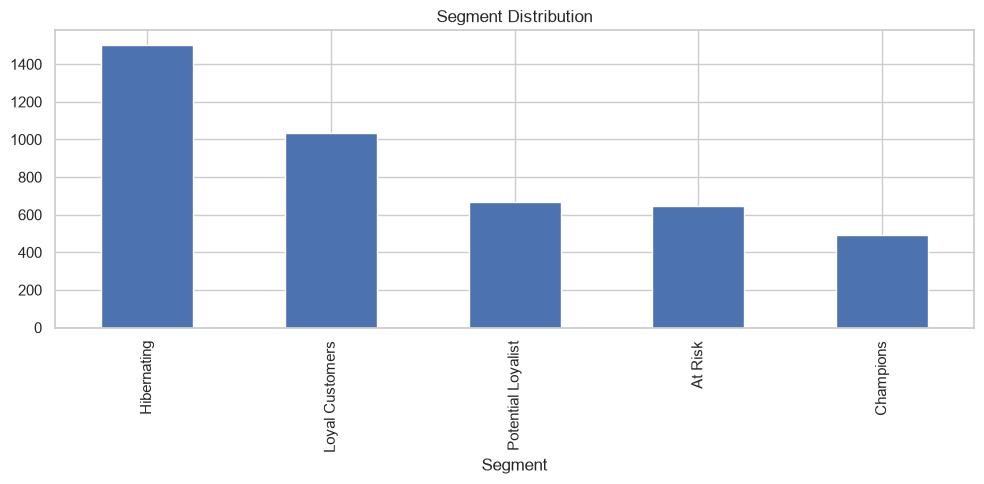

In [7]:
plt.figure(figsize=(10, 5))
rfm['Segment'].value_counts().plot(kind='bar')
plt.title('Segment Distribution')
plt.tight_layout()


In [8]:
clustered, model = run_kmeans_segmentation(rfm[['CustomerID','Recency','Frequency','Monetary']].copy(), n_clusters=4)
clustered.head()


,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346.0,326,1,77183.60,2
1,12347.0,2,7,4310.00,1
2,12348.0,75,4,1797.24,2
3,12349.0,19,1,1757.55,0
4,12350.0,310,1,334.40,3


In [9]:
segment_summary = rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean().sort_values('Monetary', ascending=False)
segment_summary


,Recency,Frequency,Monetary
Segment,,,
Champions,7.434694,15.514286,9050.497408
Loyal Customers,22.636012,5.217812,2097.416671
At Risk,119.198142,4.171827,1611.350915
Potential Loyalist,25.251128,1.448120,754.816872
Hibernating,186.571144,1.251330,510.071039


## Notes

Start with rule-based segments for storytelling, then compare them with KMeans clusters.
